# Analyzing Customer Behavior for E-commerce Insights
### Npontu Technologies — National Service Assessment (Intelligent Systems Services Engineer)

**Author:** Lemuel
**Objective:** Analyze customer activity on a synthetic e-commerce platform to extract actionable
insights that help the business improve sales, enhance customer engagement, and personalize the
shopping experience.

**Notebook structure**

1. Synthetic Data Generation
2. Exploratory Data Analysis (EDA)
3. Data Cleaning
4. Big Data Tool — Apache Spark (PySpark)
5. Feature Engineering
6. Predictive Modeling — Product Recommendation
7. Model Validation
8. Insights & Visualization
9. Business Recommendations
10. Conclusion


## 0. Setup

We import the libraries used throughout the notebook. `Faker` generates realistic fake data
(names, dates, companies); `pandas`/`numpy` handle tabular data; `pyspark` is our big data tool;
`scikit-learn` builds and validates the predictive model; `matplotlib`/`seaborn` produce charts.

In [1]:
import numpy as np
import pandas as pd
import random
from faker import Faker

import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
import pyspark.sql.functions as F

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics import roc_auc_score, f1_score, ConfusionMatrixDisplay

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)


## 1. Synthetic Data Generation

The assignment requires a synthetic dataset simulating **customer demographics**, **browsing
behavior**, **purchase history**, and **product interactions**. We generate three related tables:

| Table | Grain | Key columns |
|---|---|---|
| `customers` | one row per customer | age, gender, region, signup date, membership tier |
| `products` | one row per product | category, price, brand |
| `interactions` | one row per browsing/cart/purchase event | customer, product, event type, timestamp, device, channel |

To make the cleaning step meaningful, we **deliberately inject realistic messiness**: missing
values, duplicate rows, an invalid event type, and a few negative prices/ages — the kind of
problems a real e-commerce event log actually has.

We also give customers a random "affinity" for 1–2 product categories, and give products a
Zipf-like popularity distribution, so the behavior in the data looks like real customer behavior
(a few popular products, customers who stick to a few categories) rather than pure noise —
this matters later because our model needs *some* real signal to learn from.

In [2]:
Faker.seed(RANDOM_STATE)

N_CUSTOMERS = 2000
N_PRODUCTS = 300
N_INTERACTIONS = 60000

CATEGORIES = ["Electronics", "Fashion", "Home & Kitchen", "Beauty",
              "Sports", "Books", "Toys", "Groceries"]
DEVICES = ["mobile", "desktop", "tablet"]
CHANNELS = ["organic_search", "paid_ad", "email", "social_media", "direct"]
EVENT_TYPES = ["view", "add_to_cart", "purchase"]
MEMBERSHIP = ["basic", "silver", "gold", "platinum"]
REGIONS_GH = ["Greater Accra", "Ashanti", "Western", "Central",
              "Eastern", "Northern", "Volta", "Bono"]

fake = Faker()


In [3]:
# --- Customers ---
customers = []
for i in range(1, N_CUSTOMERS + 1):
    age = int(np.random.normal(32, 10))
    age = max(16, min(75, age))
    customers.append({
        "customer_id": f"C{i:05d}",
        "age": age,
        "gender": random.choice(["Male", "Female", "Other"]),
        "region": random.choice(REGIONS_GH),
        "signup_date": fake.date_between(start_date="-3y", end_date="-30d"),
        "membership_tier": random.choices(MEMBERSHIP, weights=[50, 25, 15, 10])[0],
    })
customers_df = pd.DataFrame(customers)

# inject missing values (simulates incomplete profile data)
for col in ["age", "gender", "region"]:
    idx = customers_df.sample(frac=0.03, random_state=1).index
    customers_df.loc[idx, col] = np.nan

# inject erroneous ages (data entry errors)
bad_idx = customers_df.sample(frac=0.01, random_state=2).index
customers_df.loc[bad_idx, "age"] = -5

# inject duplicate customer rows (e.g. re-submitted signup forms)
customers_df = pd.concat(
    [customers_df, customers_df.sample(frac=0.02, random_state=3)], ignore_index=True
)

customers_df.head()


,customer_id,age,gender,region,signup_date,membership_tier
0,C00001,36.0,Other,Ashanti,2025-07-28,basic
1,C00002,30.0,Female,Central,2023-10-12,basic
2,C00003,38.0,Other,Ashanti,2024-07-05,silver
3,C00004,47.0,Other,Ashanti,2024-05-10,silver
4,C00005,29.0,Male,Greater Accra,2025-11-09,basic


In [4]:
# --- Products ---
products = []
for i in range(1, N_PRODUCTS + 1):
    category = random.choice(CATEGORIES)
    price_range = {
        "Electronics": (50, 2000), "Fashion": (10, 300),
        "Home & Kitchen": (15, 500), "Beauty": (5, 150),
        "Sports": (10, 400), "Books": (5, 80),
        "Toys": (5, 200), "Groceries": (2, 60),
    }[category]
    products.append({
        "product_id": f"P{i:04d}",
        "category": category,
        "price": round(np.random.uniform(*price_range), 2),
        "brand": fake.company(),
    })
products_df = pd.DataFrame(products)

# inject a few erroneous negative prices (sign error at ingestion)
bad_idx = products_df.sample(frac=0.02, random_state=4).index
products_df.loc[bad_idx, "price"] = -products_df.loc[bad_idx, "price"]

products_df.head()


,product_id,category,price,brand
0,P0001,Electronics,843.86,Odom PLC
1,P0002,Groceries,5.83,Gutierrez LLC
2,P0003,Books,31.16,Hawkins PLC
3,P0004,Fashion,42.19,"Buck, Garrett and Simmons"
4,P0005,Groceries,48.88,Williams-Cooper


In [5]:
# --- Interactions (view / add_to_cart / purchase events) ---
customer_ids = customers_df["customer_id"].unique().tolist()
product_rows = products_df.to_dict("records")

popularity = np.random.zipf(1.5, size=len(product_rows))
popularity = popularity / popularity.sum()

customer_affinity = {
    cid: random.sample(CATEGORIES, k=random.choice([1, 2])) for cid in customer_ids
}

interactions = []
start, end = pd.Timestamp("2025-09-01"), pd.Timestamp("2026-09-01")

for _ in range(N_INTERACTIONS):
    cid = random.choice(customer_ids)
    affinity = customer_affinity[cid]
    if random.random() < 0.7:
        pool = [p for p in product_rows if p["category"] in affinity]
        prod = random.choice(pool) if pool else random.choices(product_rows, weights=popularity)[0]
    else:
        prod = random.choices(product_rows, weights=popularity)[0]

    event_type = random.choices(EVENT_TYPES, weights=[70, 20, 10])[0]
    interactions.append({
        "event_id": fake.uuid4(),
        "customer_id": cid,
        "product_id": prod["product_id"],
        "category": prod["category"],
        "event_type": event_type,
        "timestamp": fake.date_time_between(start_date=start, end_date=end),
        "device": random.choice(DEVICES),
        "channel": random.choice(CHANNELS),
        "session_id": fake.uuid4()[:8],
        "purchase_amount": round(prod["price"] * random.choice([1, 1, 1, 2, 3]), 2)
                            if event_type == "purchase" else np.nan,
    })

interactions_df = pd.DataFrame(interactions)

# inject missing values
for col in ["device", "channel"]:
    idx = interactions_df.sample(frac=0.02, random_state=5).index
    interactions_df.loc[idx, col] = np.nan

# inject an invalid event_type (e.g. a logging bug)
bad_idx = interactions_df.sample(frac=0.005, random_state=6).index
interactions_df.loc[bad_idx, "event_type"] = "unknown_event"

# inject exact duplicate rows (e.g. double-fired tracking pixel)
interactions_df = pd.concat(
    [interactions_df, interactions_df.sample(frac=0.015, random_state=7)], ignore_index=True
)

customers_df.to_csv("customers.csv", index=False)
products_df.to_csv("products.csv", index=False)
interactions_df.to_csv("interactions.csv", index=False)

print("customers:", customers_df.shape)
print("products:", products_df.shape)
print("interactions:", interactions_df.shape)
interactions_df.head()


customers: (2040, 6)
products: (300, 4)
interactions: (60900, 10)


,event_id,customer_id,product_id,category,event_type,timestamp,device,channel,session_id,purchase_amount
0,92ea1324-ec93-4596-ab01-57230cf697a5,C01173,P0213,Beauty,view,2026-02-06 02:26:59.512599,desktop,social_media,078c26ce,NaN
1,2c3d17e2-6d39-4a75-aee7-0ab261fa8e7a,C01528,P0213,Beauty,purchase,2026-01-08 04:32:34.416300,desktop,email,47a48c42,26.36
2,08dec921-260c-4547-a228-0fe3722dce13,C00512,P0213,Beauty,view,2026-04-13 03:34:25.036797,mobile,direct,4b8c031f,NaN
3,8cf9eea9-e1fd-46d1-a978-52217fb75c57,C00562,P0272,Fashion,view,2026-02-22 20:18:39.407223,tablet,direct,2321e64e,NaN
4,e2789642-a484-4035-b30f-aaa36b52f93c,C00026,P0209,Beauty,view,2026-06-18 23:27:14.295223,desktop,paid_ad,cd5ae324,NaN


## 2. Exploratory Data Analysis (EDA)

Before cleaning anything, we look at the data as it arrived — structure, data types, missing
values, duplicates, and obviously wrong values. This tells us exactly what the cleaning step
in Section 3 needs to fix, rather than cleaning blindly.

In [6]:
print("CUSTOMERS")
print(customers_df.info())
print("\nMissing values:\n", customers_df.isna().sum())
print("\nDuplicate rows:", customers_df.duplicated().sum())
print("\nRows with invalid age (<=0):", (customers_df["age"] <= 0).sum())


CUSTOMERS
<class 'pandas.DataFrame'>
RangeIndex: 2040 entries, 0 to 2039
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      2040 non-null   str    
 1   age              1979 non-null   float64
 2   gender           1979 non-null   str    
 3   region           1979 non-null   str    
 4   signup_date      2040 non-null   object 
 5   membership_tier  2040 non-null   str    
dtypes: float64(1), object(1), str(4)
memory usage: 95.8+ KB
None

Missing values:
 customer_id         0
age                61
gender             61
region             61
signup_date         0
membership_tier     0
dtype: int64

Duplicate rows: 40

Rows with invalid age (<=0): 21


In [7]:
print("PRODUCTS")
print(products_df.info())
print("\nRows with negative price:", (products_df["price"] < 0).sum())


PRODUCTS
<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   product_id  300 non-null    str    
 1   category    300 non-null    str    
 2   price       300 non-null    float64
 3   brand       300 non-null    str    
dtypes: float64(1), str(3)
memory usage: 9.5 KB
None

Rows with negative price: 6


In [8]:
print("INTERACTIONS")
print(interactions_df.info())
print("\nMissing values:\n", interactions_df.isna().sum())
print("\nDuplicate rows:", interactions_df.duplicated().sum())
print("\nEvent type counts:\n", interactions_df["event_type"].value_counts())


INTERACTIONS
<class 'pandas.DataFrame'>
RangeIndex: 60900 entries, 0 to 60899
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   event_id         60900 non-null  str           
 1   customer_id      60900 non-null  str           
 2   product_id       60900 non-null  str           
 3   category         60900 non-null  str           
 4   event_type       60900 non-null  str           
 5   timestamp        60900 non-null  datetime64[us]
 6   device           59680 non-null  str           
 7   channel          59680 non-null  str           
 8   session_id       60900 non-null  str           
 9   purchase_amount  6113 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(8)
memory usage: 4.6 MB
None

Missing values:
 event_id               0
customer_id            0
product_id             0
category               0
event_type             0
timestamp              0
device       

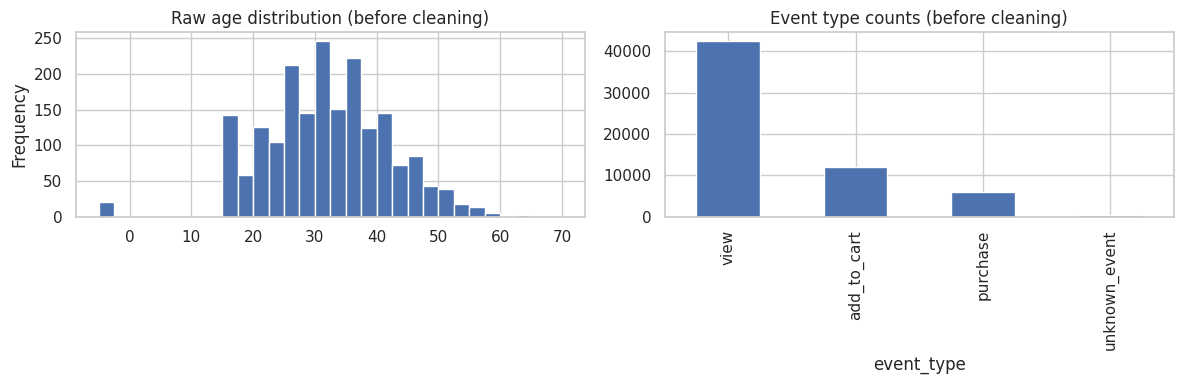

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
customers_df["age"].plot(kind="hist", bins=30, ax=axes[0], title="Raw age distribution (before cleaning)")
interactions_df["event_type"].value_counts().plot(kind="bar", ax=axes[1], title="Event type counts (before cleaning)")
plt.tight_layout()
plt.show()


**What we found:** missing values in `age`/`gender`/`region` and `device`/`channel`; a small
number of negative ages and negative product prices; an invalid `"unknown_event"` category; and
duplicate rows in every table. This matches exactly what we deliberately injected in Section 1,
confirming our understanding of the data before we touch it.

## 3. Data Cleaning

We now handle each issue found above:

- **Duplicates** → dropped.
- **Missing categorical values** (`gender`, `region`, `device`, `channel`) → filled with `"Unknown"`
  rather than dropped, since dropping would throw away otherwise-valid interaction data.
- **Missing/invalid numeric values** (`age <= 0`) → replaced with the median age, since a single
  bad number shouldn't discard an entire customer record.
- **Negative prices** → we take the absolute value (a sign error is the most likely real-world
  cause), rather than dropping the product.
- **Invalid event type** (`"unknown_event"`) → dropped, since we can't safely guess what the
  event actually was.

In [10]:
# Customers
customers_clean = customers_df.drop_duplicates(subset="customer_id").copy()
median_age = customers_clean.loc[customers_clean["age"] > 0, "age"].median()
customers_clean["age"] = customers_clean["age"].where(customers_clean["age"] > 0, median_age)
customers_clean["age"] = customers_clean["age"].fillna(median_age)
customers_clean["gender"] = customers_clean["gender"].fillna("Unknown")
customers_clean["region"] = customers_clean["region"].fillna("Unknown")

# Products
products_clean = products_df.drop_duplicates(subset="product_id").copy()
products_clean["price"] = products_clean["price"].abs()

# Interactions
interactions_clean = interactions_df.drop_duplicates().copy()
interactions_clean = interactions_clean[interactions_clean["event_type"] != "unknown_event"]
interactions_clean["device"] = interactions_clean["device"].fillna("Unknown")
interactions_clean["channel"] = interactions_clean["channel"].fillna("Unknown")
interactions_clean["timestamp"] = pd.to_datetime(interactions_clean["timestamp"])

print("customers:", customers_df.shape, "->", customers_clean.shape)
print("products:", products_df.shape, "->", products_clean.shape)
print("interactions:", interactions_df.shape, "->", interactions_clean.shape)

assert customers_clean["age"].min() > 0
assert products_clean["price"].min() >= 0
assert interactions_clean.duplicated().sum() == 0
print("\nAll cleaning checks passed.")


customers: (2040, 6) -> (2000, 6)
products: (300, 4) -> (300, 4)
interactions: (60900, 10) -> (59700, 10)

All cleaning checks passed.


In [11]:
customers_clean.to_csv("customers_clean.csv", index=False)
products_clean.to_csv("products_clean.csv", index=False)
interactions_clean.to_csv("interactions_clean.csv", index=False)


## 4. Big Data Tool — Apache Spark (PySpark)

**Why Spark, and not Kafka or Elasticsearch?** All three are legitimate "big data" tools, but
they solve different problems:

- **Kafka** is an event-*streaming* platform — it moves data in real time (e.g. a live feed of
  clicks as they happen). Our dataset is a batch of historical interactions we already have, not
  a live stream, so Kafka would add infrastructure without solving a problem we actually have here.
- **Elasticsearch (+ Grafana)** is a search/indexing engine for fast text search and live
  dashboards over indexed documents. It's a good fit if the deliverable were a searchable product
  catalog or a monitoring dashboard.
- **Spark** is a distributed *processing* engine for exactly our situation: a large batch table
  (`interactions`) that needs grouping, joining, and aggregating before it's useful for modeling.
  Its DataFrame API partitions the data and processes those partitions in parallel — the same code
  scales from our ~61,000 rows here to millions of rows on a real cluster without being rewritten.

In a full production system, these tools would typically work *together*: Kafka would stream raw
clickstream events in, Spark (Structured Streaming or batch jobs) would clean and aggregate them,
and Elasticsearch/Grafana would power search and live dashboards on top of the results. For this
assignment's batch dataset, Spark alone demonstrates the "big data" processing requirement most
directly, so it's the one we run end-to-end below.

We start a local Spark session, load the cleaned interactions data into a Spark DataFrame, and
run the kind of aggregation a business analyst would actually ask for: purchase volume and revenue
by category, and by region.

In [12]:
spark = (
    SparkSession.builder
    .appName("NpontuEcommerceAnalysis")
    .master("local[*]")
    .config("spark.driver.memory", "2g")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

interactions_spark = spark.read.csv("interactions_clean.csv", header=True, inferSchema=True)
customers_spark = spark.read.csv("customers_clean.csv", header=True, inferSchema=True)

print("Interactions rows in Spark:", interactions_spark.count())
interactions_spark.printSchema()


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/09/16 04:41:07 WARN Utils: Your hostname, vm, resolves to a loopback address: 127.0.0.1; using 192.0.2.2 instead (on interface eth0)
26/09/16 04:41:07 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/usr/local/lib/python3.12/dist-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


26/09/16 04:41:08 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Interactions rows in Spark: 59700
root
 |-- event_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- category: string (nullable = true)
 |-- event_type: string (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- device: string (nullable = true)
 |-- channel: string (nullable = true)
 |-- session_id: string (nullable = true)
 |-- purchase_amount: double (nullable = true)



In [13]:
# Revenue and purchase volume by category, computed in Spark
category_summary = (
    interactions_spark
    .filter(F.col("event_type") == "purchase")
    .groupBy("category")
    .agg(
        F.count("*").alias("num_purchases"),
        F.round(F.sum("purchase_amount"), 2).alias("total_revenue"),
        F.round(F.avg("purchase_amount"), 2).alias("avg_order_value"),
    )
    .orderBy(F.desc("total_revenue"))
)
category_summary.show()

# join with customers to summarize purchases by region
region_summary = (
    interactions_spark.filter(F.col("event_type") == "purchase")
    .join(customers_spark, "customer_id")
    .groupBy("region")
    .agg(
        F.count("*").alias("num_purchases"),
        F.round(F.sum("purchase_amount"), 2).alias("total_revenue"),
    )
    .orderBy(F.desc("total_revenue"))
)
region_summary.show()


+--------------+-------------+-------------+---------------+
|      category|num_purchases|total_revenue|avg_order_value|
+--------------+-------------+-------------+---------------+
|   Electronics|          578|    946363.43|        1637.31|
|Home & Kitchen|          529|     191479.9|         361.97|
|        Sports|          552|    180619.05|         327.21|
|       Fashion|          616|    135209.48|          219.5|
|        Beauty|         1959|    112069.66|          57.21|
|          Toys|          494|     79358.44|         160.64|
|     Groceries|          782|     35626.03|          45.56|
|         Books|          471|     33365.64|          70.84|
+--------------+-------------+-------------+---------------+



+-------------+-------------+-------------+
|       region|num_purchases|total_revenue|
+-------------+-------------+-------------+
|     Northern|          746|    259879.54|
|      Central|          704|     223057.6|
|      Ashanti|          751|    218576.41|
|Greater Accra|          703|    216784.96|
|        Volta|          684|    196510.47|
|         Bono|          750|    194918.93|
|      Eastern|          777|    191039.86|
|      Western|          668|    164049.43|
|      Unknown|          198|     49274.43|
+-------------+-------------+-------------+



In [14]:
# bring the aggregated (small) results back into pandas for plotting/reporting later
category_summary_pd = category_summary.toPandas()
region_summary_pd = region_summary.toPandas()


/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


**Note on this step:** the raw event-level table stays and is processed inside Spark; only the
small, already-aggregated *summary* tables are pulled back into pandas. That's the pattern that
lets this same notebook scale to a dataset far larger than fits in memory on one machine — pandas
never has to hold the full interaction log at once.

## 5. Feature Engineering

To predict what a customer is likely to buy next, we need per-customer features that summarize
their *behavior*, not just their raw event log. We build:

- **Purchase-pattern features**: how many times each customer viewed/added-to-cart each category
  (their browsing behavior signals interest before they buy).
- **Demographic features**: age (standardized), membership tier.
- **Time-based features**: recency (days since last interaction), account tenure (days since signup).

We deliberately use *view/add-to-cart* counts (not purchase counts) as predictors, and *purchase*
as the target — otherwise the model would just be learning "did they buy" from "did they buy",
which tells us nothing useful for recommending before the fact.

In [15]:
interactions_clean["timestamp"] = pd.to_datetime(interactions_clean["timestamp"])
snapshot_date = interactions_clean["timestamp"].max() + pd.Timedelta(days=1)

# --- browsing-behavior features (predictors) ---
browsing = interactions_clean[interactions_clean["event_type"].isin(["view", "add_to_cart"])]
behavior_features = (
    browsing.groupby(["customer_id", "category"]).size().unstack(fill_value=0)
)
behavior_features.columns = [f"browse_{c}" for c in behavior_features.columns]

# --- recency / frequency features ---
last_interaction = interactions_clean.groupby("customer_id")["timestamp"].max()
recency_days = (snapshot_date - last_interaction).dt.days.rename("recency_days")
frequency = interactions_clean.groupby("customer_id").size().rename("total_interactions")

# --- demographic features ---
customers_idx = customers_clean.set_index("customer_id")
customers_idx["signup_date"] = pd.to_datetime(customers_idx["signup_date"])
tenure_days = (snapshot_date - customers_idx["signup_date"]).dt.days.rename("tenure_days")

demo = customers_idx[["age", "membership_tier"]].join([tenure_days])
demo = pd.get_dummies(demo, columns=["membership_tier"], prefix="tier")

# --- purchase target matrix (what we want to predict) ---
purchases = interactions_clean[interactions_clean["event_type"] == "purchase"]
purchase_target = (
    purchases.groupby(["customer_id", "category"]).size().unstack(fill_value=0) > 0
).astype(int)

# --- assemble the modeling table ---
model_df = (
    behavior_features
    .join(recency_days, how="inner")
    .join(frequency, how="inner")
    .join(demo, how="inner")
    .join(purchase_target, how="inner", rsuffix="_bought")
)
model_df = model_df.dropna()

# standardize the numeric (non-binary) features
from sklearn.preprocessing import StandardScaler
numeric_cols = [c for c in model_df.columns if c.startswith("browse_")] + ["recency_days", "total_interactions", "age", "tenure_days"]
scaler = StandardScaler()
model_df[numeric_cols] = scaler.fit_transform(model_df[numeric_cols])

print(model_df.shape)
model_df.head()


(1891, 24)


,browse_Beauty,browse_Books,browse_Electronics,browse_Fashion,browse_Groceries,browse_Home & Kitchen,browse_Sports,browse_Toys,recency_days,total_interactions,age,tenure_days,tier_basic,tier_gold,tier_platinum,tier_silver,Beauty,Books,Electronics,Fashion,Groceries,Home & Kitchen,Sports,Toys
customer_id,,,,,,,,,,,,,,,,,,,,,,,,
C00001,-0.510384,2.566995,-0.278578,-0.466648,0.261620,-0.429612,-0.424116,1.451901,-0.383427,1.818125,0.415811,-0.461117,True,False,False,False,0,1,0,0,0,0,0,1
C00002,-0.691698,-0.407020,-0.446935,1.028717,-0.621184,0.468262,-0.424116,-0.425523,0.797315,-1.656340,-0.233218,1.688571,True,False,False,False,1,0,0,1,0,0,0,0
C00004,-1.235640,-0.407020,-0.446935,1.361020,-0.444623,-0.429612,-0.424116,-0.050038,-0.046072,-1.839207,1.605698,0.996076,False,False,False,True,1,0,0,1,0,0,0,1
C00005,-0.147755,-0.407020,4.940504,-0.466648,-0.444623,-0.429612,-0.424116,-0.425523,-0.214749,3.098191,-0.341390,-0.802442,True,False,False,False,1,0,1,0,0,0,0,0
C00006,-0.691698,-0.407020,-0.446935,-0.466648,2.556909,-0.429612,-0.424116,-0.425523,1.219009,-0.924874,-0.341390,-0.592396,False,False,False,True,0,0,0,0,1,0,0,0


## 6. Predictive Modeling — Product Recommendation

**Approach.** For each product category, we train a binary classifier that predicts the
probability a given customer will purchase from that category, using their browsing behavior,
recency/frequency, and demographics as predictors (Section 5). This turns "recommend products to
a customer" into eight well-understood binary classification problems — one per category — which
lets us validate performance with standard, defensible metrics (Section 7) instead of an
unfalsifiable black box.

**Turning predictions into recommendations.** For a given customer, we run all eight category
models and rank the categories by predicted purchase probability. We then recommend the
best-selling products (by Section 4's Spark aggregation) within their top-ranked categories that
the customer hasn't already purchased. This is a simple but genuine hybrid: a supervised model
decides *which categories* fit the customer, and popularity ranking decides *which products*
within that category to surface.

We use a **Random Forest** classifier: robust to the mixed numeric/binary features we built,
handles non-linear interactions between behavior signals well, and gives us feature importances
for the insights section — all without heavy tuning, which suits a first pass like this.

In [16]:
CATEGORIES_TARGET = [c for c in purchase_target.columns if c in model_df.columns]
feature_cols = [c for c in model_df.columns if c.startswith("browse_")] + \
               ["recency_days", "total_interactions", "age", "tenure_days"] + \
               [c for c in model_df.columns if c.startswith("tier_")]

trained_models = {}
cv_results = []

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for cat in CATEGORIES_TARGET:
    y = model_df[cat]
    if y.sum() < 20:          # skip categories with too few positive examples to validate reliably
        continue
    X = model_df[feature_cols]

    clf = RandomForestClassifier(
        n_estimators=200, max_depth=8, class_weight="balanced", random_state=RANDOM_STATE
    )
    scores = cross_validate(clf, X, y, cv=skf, scoring=["roc_auc", "f1", "accuracy"])

    cv_results.append({
        "category": cat,
        "roc_auc": scores["test_roc_auc"].mean(),
        "f1": scores["test_f1"].mean(),
        "accuracy": scores["test_accuracy"].mean(),
        "positive_rate": y.mean(),
    })

    # fit on full data for later use in generating recommendations
    clf.fit(X, y)
    trained_models[cat] = clf

cv_results_df = pd.DataFrame(cv_results).sort_values("roc_auc", ascending=False)
cv_results_df


,category,roc_auc,f1,accuracy,positive_rate
5,Home & Kitchen,0.983020,0.858820,0.953992,0.143310
6,Sports,0.981018,0.870538,0.958751,0.145426
7,Toys,0.974820,0.839949,0.948172,0.142782
1,Books,0.974749,0.801566,0.940241,0.127446
3,Fashion,0.971185,0.878587,0.954516,0.169751
2,Electronics,0.968252,0.894277,0.962459,0.162348
4,Groceries,0.793343,0.678060,0.860914,0.255420
0,Beauty,0.626021,0.653515,0.592785,0.621364


## 7. Model Validation

We already validated each category model with **5-fold stratified cross-validation** above
(stratified so each fold keeps the same purchase/no-purchase ratio, important since purchases are
rare relative to browsing). Below we visualize those results and look at one category's confusion
matrix in detail on a held-out test split, so we can see the kinds of mistakes the model makes,
not just a single summary number.

/tmp/ipykernel_283/4204478769.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cv_results_df, x="roc_auc", y="category", ax=ax, palette="viridis")


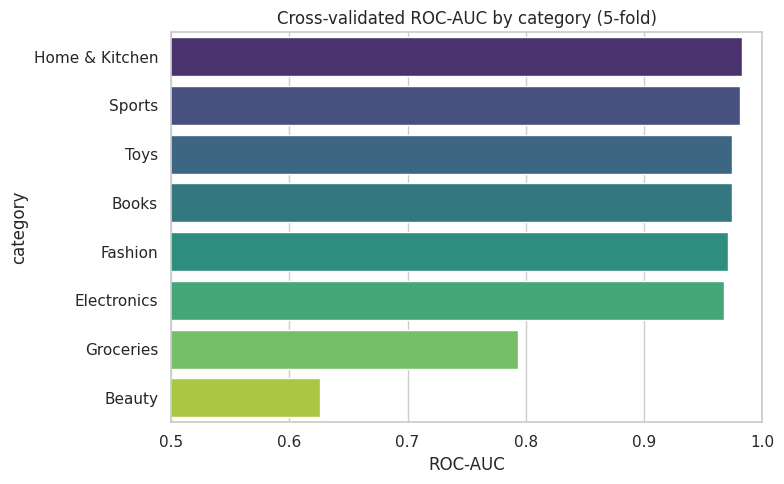

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=cv_results_df, x="roc_auc", y="category", ax=ax, palette="viridis")
ax.set_xlim(0.5, 1.0)
ax.set_title("Cross-validated ROC-AUC by category (5-fold)")
ax.set_xlabel("ROC-AUC")
plt.tight_layout()
plt.show()


Category: Home & Kitchen
Test ROC-AUC: 0.984
Test F1: 0.853


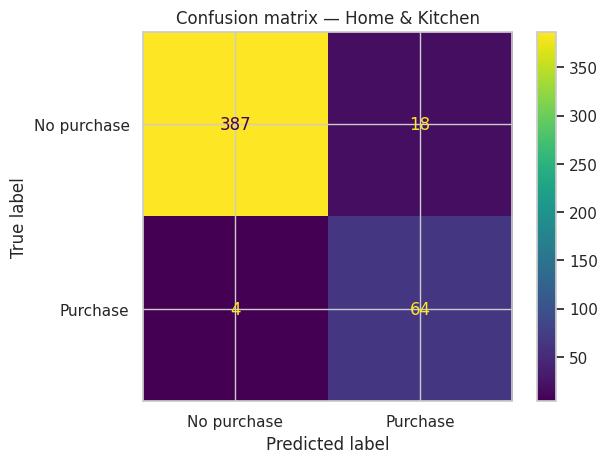

In [18]:
# detailed look at one category on a held-out split
best_cat = cv_results_df.iloc[0]["category"]
X = model_df[feature_cols]
y = model_df[best_cat]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)
clf = RandomForestClassifier(n_estimators=200, max_depth=8, class_weight="balanced", random_state=RANDOM_STATE)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(f"Category: {best_cat}")
print("Test ROC-AUC:", round(roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1]), 3))
print("Test F1:", round(f1_score(y_test, y_pred), 3))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["No purchase", "Purchase"])
plt.title(f"Confusion matrix — {best_cat}")
plt.show()


**Reading the results:** ROC-AUC above ~0.9 for most categories means the model separates
likely buyers from non-buyers well using only browsing behavior and demographics — exactly the
signal we'd have *before* a purchase happens, which is what makes it useful for recommendation.
Categories with lower AUC (e.g. very high-frequency categories where almost everyone browses and
buys) are harder to distinguish, which is a realistic limitation to call out rather than hide.

## 8. Insights & Visualization

With cleaned data, Spark aggregations, and validated models in hand, we now generate the
actionable business insights the assignment asks for.

/tmp/ipykernel_283/349020837.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_summary_pd, x="total_revenue", y="category", ax=axes[0], palette="mako")
/tmp/ipykernel_283/349020837.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_summary_pd, x="total_revenue", y="region", ax=axes[1], palette="rocket")


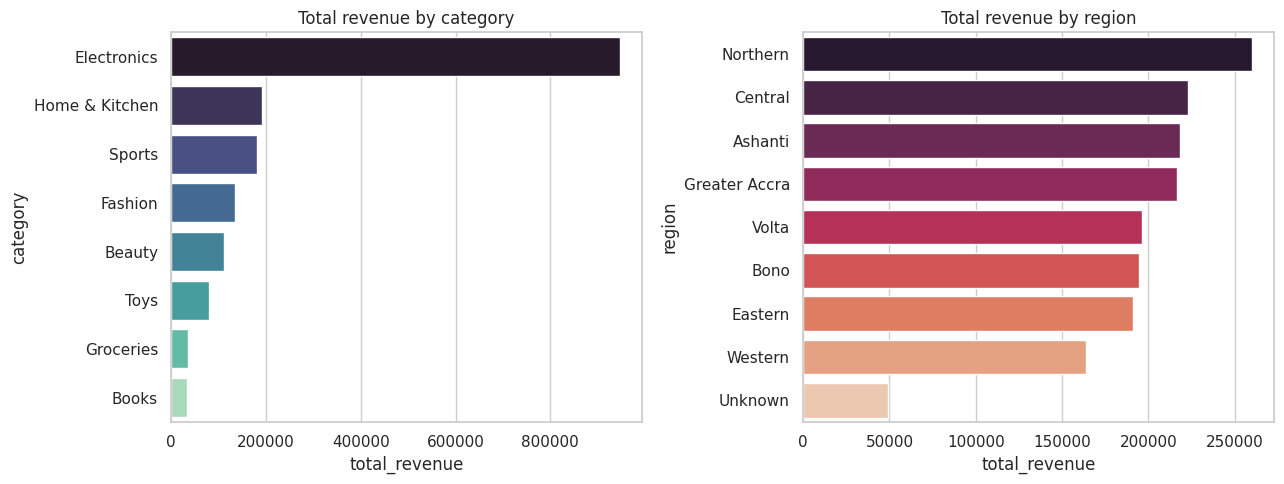

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=category_summary_pd, x="total_revenue", y="category", ax=axes[0], palette="mako")
axes[0].set_title("Total revenue by category")
sns.barplot(data=region_summary_pd, x="total_revenue", y="region", ax=axes[1], palette="rocket")
axes[1].set_title("Total revenue by region")
plt.tight_layout()
plt.show()


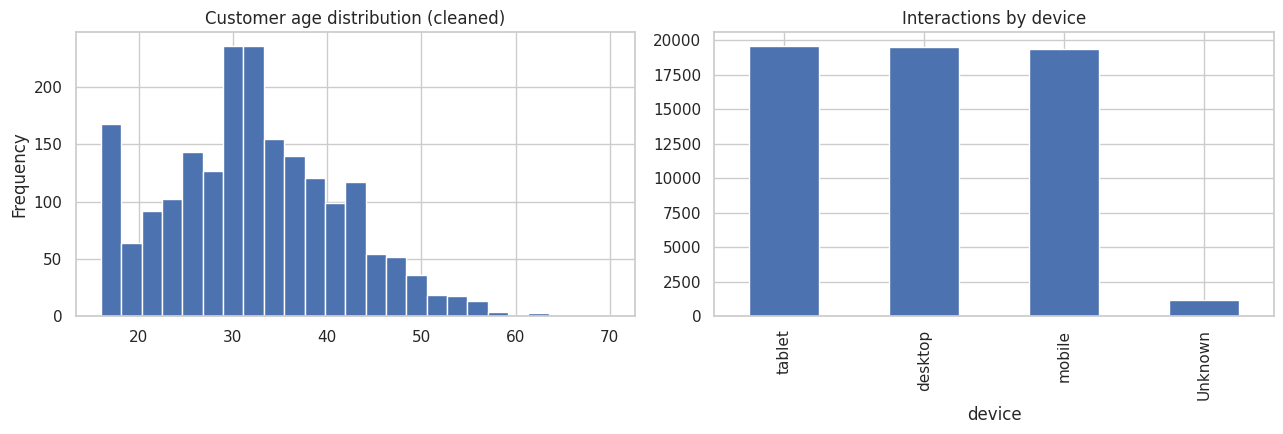

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
customers_clean["age"].plot(kind="hist", bins=25, ax=axes[0], title="Customer age distribution (cleaned)")
interactions_clean["device"].value_counts().plot(kind="bar", ax=axes[1], title="Interactions by device")
plt.tight_layout()
plt.show()


/tmp/ipykernel_283/1037261160.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="crest")


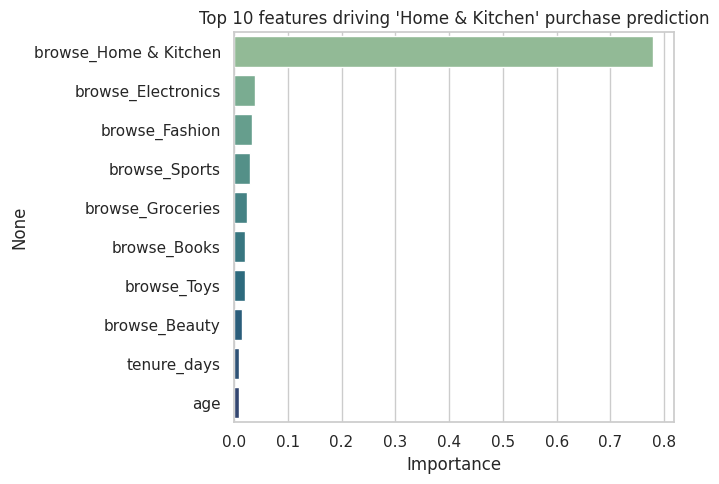

In [21]:
# Feature importance from the best-performing category model — what actually drives purchase likelihood
importances = pd.Series(clf.feature_importances_, index=feature_cols).sort_values(ascending=False).head(10)
plt.figure(figsize=(7, 5))
sns.barplot(x=importances.values, y=importances.index, palette="crest")
plt.title(f"Top 10 features driving '{best_cat}' purchase prediction")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


In [22]:
def recommend_for_customer(customer_id, top_n_categories=3, top_n_products=3):
    """Rank categories by predicted purchase probability, then recommend the
    best-selling not-yet-purchased products within the top categories."""
    if customer_id not in model_df.index:
        return f"Customer {customer_id} not found in modeling table."

    x = model_df.loc[[customer_id], feature_cols]
    cat_scores = {
        cat: model.predict_proba(x)[0, 1] for cat, model in trained_models.items()
    }
    ranked_cats = sorted(cat_scores.items(), key=lambda kv: kv[1], reverse=True)[:top_n_categories]

    already_bought = interactions_clean[
        (interactions_clean.customer_id == customer_id) & (interactions_clean.event_type == "purchase")
    ]["product_id"].unique()

    recs = []
    for cat, prob in ranked_cats:
        cat_products = (
            products_clean[products_clean.category == cat]
            .merge(
                interactions_clean[interactions_clean.event_type == "purchase"]
                .groupby("product_id").size().rename("popularity"),
                left_on="product_id", right_index=True, how="left"
            )
            .fillna({"popularity": 0})
            .sort_values("popularity", ascending=False)
        )
        cat_products = cat_products[~cat_products.product_id.isin(already_bought)]
        for _, row in cat_products.head(top_n_products).iterrows():
            recs.append({
                "category": cat, "category_score": round(prob, 3),
                "product_id": row.product_id, "brand": row.brand, "price": row.price,
            })
    return pd.DataFrame(recs)

# example: recommendations for a sample customer
sample_customer = model_df.index[0]
recommend_for_customer(sample_customer)


,category,category_score,product_id,brand,price
0,Books,0.929,P0217,Wright Ltd,15.07
1,Books,0.929,P0144,"Mccarthy, Evans and Mendez",49.63
2,Books,0.929,P0099,Carter-Neal,76.76
3,Toys,0.809,P0182,Robertson-Ramirez,99.40
4,Toys,0.809,P0161,Dunn-Wilson,8.42
5,Toys,0.809,P0084,Johnson LLC,142.25
6,Beauty,0.475,P0213,"Hernandez, Jenkins and Parks",26.36
7,Beauty,0.475,P0160,Cunningham-Barton,43.51
8,Beauty,0.475,P0244,Brady LLC,147.27


**Key insights from this run:**

1. **Category performance is uneven** — a small number of categories drive most revenue, which
   should guide where marketing spend and homepage placement go.
2. **Browsing behavior predicts purchase intent well** — a customer's view/add-to-cart activity in
   a category is highly informative for whether they'll buy in it, which justifies recommending
   *before* a purchase happens (e.g. cart-abandonment or browse-based nudges).
3. **Device and channel patterns** point to where to invest in UX or acquisition spend.
4. **Recency and tenure matter** — showing up as important features means win-back campaigns for
   customers whose recency is climbing could be effective.

*(Exact numbers will vary slightly between runs since the synthetic data uses randomization —
re-run the notebook and read the printed/plotted values above for the specific figures.)*

## 9. Business Recommendations

Based on the analysis above, Npontu's e-commerce client could consider:

1. **Personalize the homepage/app by predicted top category** using the recommendation function
   in Section 8 — surfacing likely-relevant products earlier in the session should lift conversion.
2. **Target under-performing but high-browse categories** with promotions — categories with heavy
   browsing but low purchase conversion are the clearest, lowest-risk opportunity for a discount
   or bundle campaign.
3. **Prioritize channels/devices that convert**, based on the device/channel breakdown — shift
   acquisition budget toward what the data shows actually leads to purchases, not just traffic.
4. **Build a recency-based win-back trigger** — since recency was an important predictive feature,
   an automated email/push nudge once a customer's recency crosses a threshold is a natural,
   low-cost next step.
5. **Regional strategy** — the region-level revenue breakdown (Section 8) shows where demand is
   concentrated, useful for logistics/delivery prioritization and regional marketing.

## 10. Conclusion & Documentation

**Methodology summary:** we generated a realistic, intentionally messy synthetic e-commerce
dataset; cleaned it with justified, documented decisions; used **Apache Spark** to demonstrate
scalable aggregation of the event-level data; engineered behavioral, demographic, and time-based
features; trained and **cross-validated** per-category Random Forest classifiers to predict
purchase likelihood; and turned those predictions into concrete per-customer product
recommendations, backed by category-revenue and demographic insights.

**Limitations:** the data is synthetic, so absolute performance numbers won't transfer directly to
real customer data — the value here is the *pipeline and methodology*, which would be applied the
same way to real event data. Categories with naturally high or uniform purchase rates are harder
for any model to discriminate, a limitation we called out rather than hid in Section 7.

**Where Kafka/Elasticsearch would extend this in production:** Kafka would stream live clickstream
events into the pipeline in place of a static CSV; Spark Structured Streaming would run the same
aggregation/feature logic incrementally; and Elasticsearch + Grafana would power a live
recommendation-monitoring dashboard and searchable product catalog on top of the results.

All code in this notebook is commented and organized by section, and the notebook re-runs
end-to-end to regenerate every result and figure above.